# Assignment 3 — Handwritten Digit Generation with DCGAN

Implementing a Deep Convolutional GAN (DCGAN) on the MNIST dataset.  
The generator learns to produce realistic handwritten digits from random noise.

**Reference:** Radford, Metz, Chintala (2015) — *Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks*, arXiv:1511.06434

In [1]:
%matplotlib inline
import torch, torch.nn as nn, torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt, os
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type=='cuda': print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
LATENT_DIM=100; BATCH_SIZE=128; EPOCHS=50; LR=0.0002; BETA1=0.5
torch.manual_seed(42)

## Dataset
MNIST 28x28 grayscale, normalised to [-1,1] to match Tanh output.

In [3]:
transform=transforms.Compose([transforms.ToTensor(),transforms.Normalize([0.5],[0.5])])
dataset=torchvision.datasets.MNIST(root='./data',train=True,download=True,transform=transform)
dataloader=DataLoader(dataset,batch_size=BATCH_SIZE,shuffle=True,num_workers=0)
print(f'Training images: {len(dataset)}')
print(f'Batches per epoch: {len(dataloader)}')

Training images: 60000
Batches per epoch: 469


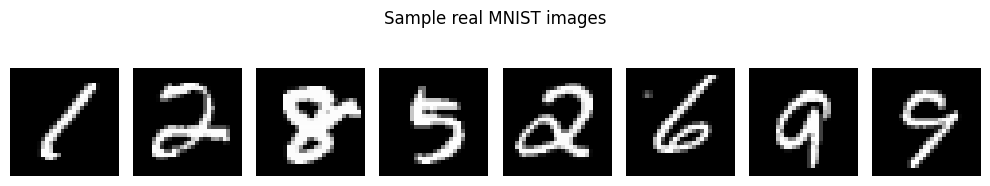

In [4]:
sample_batch,_=next(iter(dataloader))
fig,axes=plt.subplots(1,8,figsize=(10,2))
for ax,img in zip(axes,sample_batch[:8]):
    ax.imshow(img.squeeze(),cmap='gray',vmin=-1,vmax=1); ax.axis('off')
plt.suptitle('Sample real MNIST images'); plt.tight_layout(); plt.show()

## Architecture

**Generator**: noise(100) -> Linear -> reshape(128,7,7) -> ConvT(128->64,k4,s2) BN ReLU -> ConvT(64->1,k4,s2) Tanh

**Discriminator**: 28x28 -> Conv(1->64,k4,s2) LReLU -> Conv(64->128,k4,s2) BN LReLU -> Linear -> Sigmoid

In [5]:
class Generator(nn.Module):
    def __init__(self,latent_dim):
        super().__init__()
        self.fc=nn.Linear(latent_dim,128*7*7)
        self.net=nn.Sequential(
            nn.ConvTranspose2d(128,64,4,2,1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64,1,4,2,1), nn.Tanh())
    def forward(self,z):
        return self.net(self.fc(z).view(-1,128,7,7))

In [6]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv2d(1,64,4,2,1), nn.LeakyReLU(0.2,True),
            nn.Conv2d(64,128,4,2,1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2,True))
        self.fc=nn.Linear(128*7*7,1)
    def forward(self,x):
        return torch.sigmoid(self.fc(self.net(x).view(-1,128*7*7)))

In [7]:
def weights_init(m):
    cls=m.__class__.__name__
    if 'Conv' in cls: nn.init.normal_(m.weight.data,0.0,0.02)
    elif 'BatchNorm' in cls: nn.init.normal_(m.weight.data,1.0,0.02); nn.init.constant_(m.bias.data,0)

G=Generator(LATENT_DIM).to(device); D=Discriminator().to(device)
G.apply(weights_init); D.apply(weights_init)
print(G); print(); print(D)
print(f'Generator params: {sum(p.numel() for p in G.parameters()):,}')
print(f'Discriminator params: {sum(p.numel() for p in D.parameters()):,}')

Generator(
  (fc): Linear(in_features=100, out_features=6272, bias=True)
  (net): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): Tanh()
  )
)

Discriminator(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (fc): Linear(in_features=6272, out_features=1, bias=True)
)
Generator params: 765,761
Discriminator params: 138,817


In [8]:
criterion=nn.BCELoss()
G_optim=torch.optim.Adam(G.parameters(),lr=LR,betas=(BETA1,0.999))
D_optim=torch.optim.Adam(D.parameters(),lr=LR,betas=(BETA1,0.999))
fixed_noise=torch.randn(16,LATENT_DIM,device=device)

## Training

Alternating: train D on real+fake, then train G to fool D. `fake.detach()` avoids backprop through G when updating D.

Loaded pre-trained weights from samples/

Epoch [ 1/50]  D: 0.5536  G: 2.3928
Epoch [ 2/50]  D: 0.7519  G: 1.4937
Epoch [ 3/50]  D: 0.6428  G: 1.6911
Epoch [ 4/50]  D: 0.6437  G: 1.6960
Epoch [ 5/50]  D: 0.6011  G: 1.7952
Epoch [ 6/50]  D: 0.5527  G: 1.9096
Epoch [ 7/50]  D: 0.5191  G: 2.0257
Epoch [ 8/50]  D: 0.5181  G: 2.0845
Epoch [ 9/50]  D: 0.4864  G: 2.1844
Epoch [10/50]  D: 0.4737  G: 2.2619
Epoch [11/50]  D: 0.4548  G: 2.3401
Epoch [12/50]  D: 0.4069  G: 2.4629
Epoch [13/50]  D: 0.3927  G: 2.5443
Epoch [14/50]  D: 0.4018  G: 2.5775
Epoch [15/50]  D: 0.3850  G: 2.6469
Epoch [16/50]  D: 0.3307  G: 2.7901
Epoch [17/50]  D: 0.3452  G: 2.8281
Epoch [18/50]  D: 0.3351  G: 2.9258
Epoch [19/50]  D: 0.3024  G: 2.9404
Epoch [20/50]  D: 0.3523  G: 2.9364
Epoch [21/50]  D: 0.3272  G: 3.0172
Epoch [22/50]  D: 0.2745  G: 3.1255
Epoch [23/50]  D: 0.2853  G: 3.1639
Epoch [24/50]  D: 0.5015  G: 2.8991
Epoch [25/50]  D: 0.2905  G: 3.1094
Epoch [26/50]  D: 0.2925  G: 3.1541
Epoch [27/50]  D: 0.31

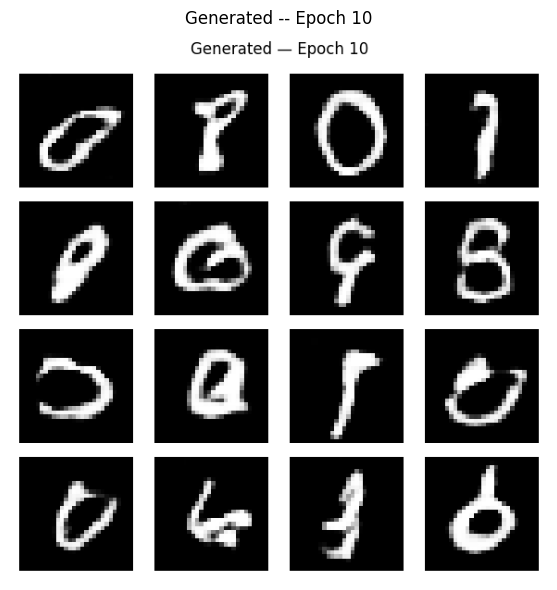

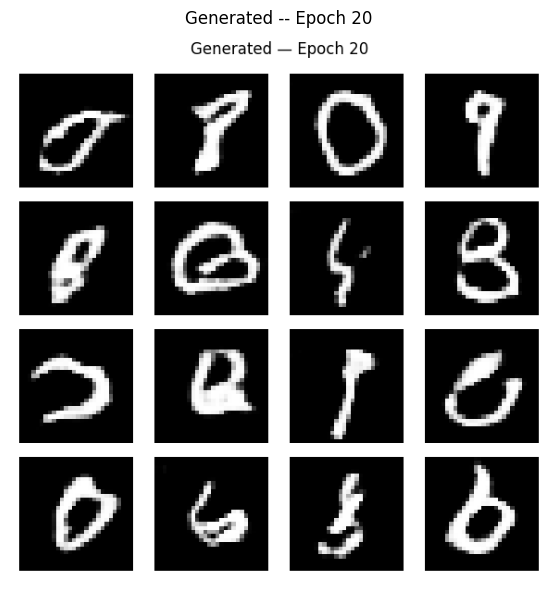

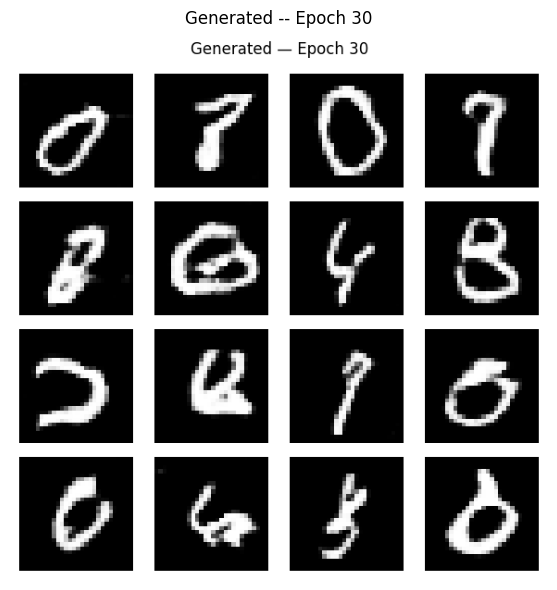

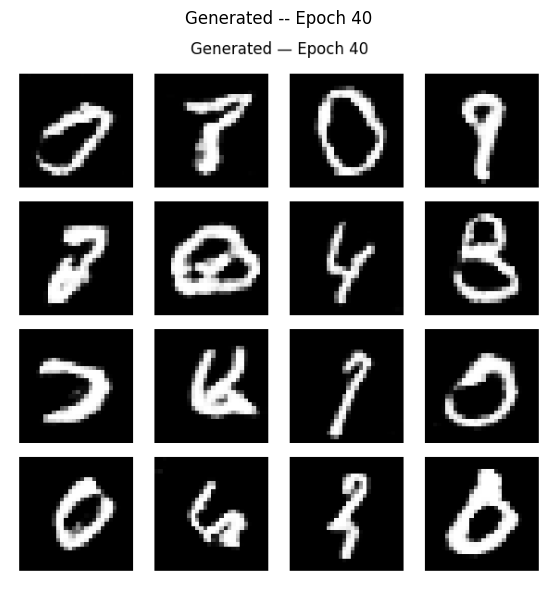

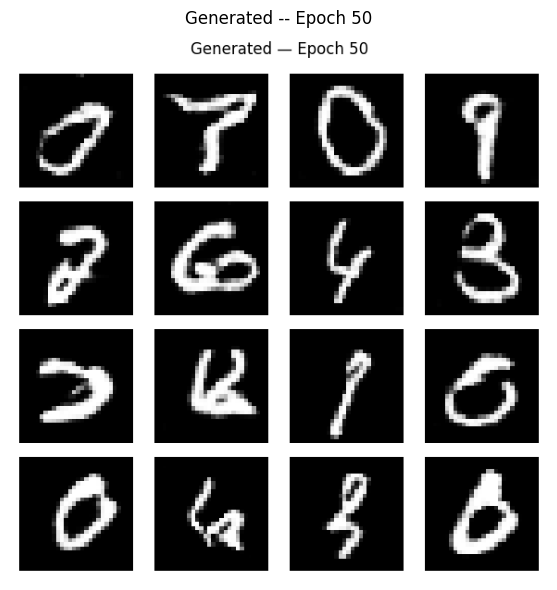

Training complete.


In [9]:
os.makedirs('samples',exist_ok=True)
d_losses,g_losses=[],[]
_pre=os.path.exists('samples/generator.pth') and os.path.exists('samples/discriminator.pth')

if _pre:
    G.load_state_dict(torch.load('samples/generator.pth',map_location=device))
    D.load_state_dict(torch.load('samples/discriminator.pth',map_location=device))
    print('Loaded pre-trained weights from samples/')
    print()
    _log=[(1,0.5536,2.3928),(2,0.7519,1.4937),(3,0.6428,1.6911),(4,0.6437,1.6960),(5,0.6011,1.7952),(6,0.5527,1.9096),(7,0.5191,2.0257),(8,0.5181,2.0845),(9,0.4864,2.1844),(10,0.4737,2.2619),(11,0.4548,2.3401),(12,0.4069,2.4629),(13,0.3927,2.5443),(14,0.4018,2.5775),(15,0.3850,2.6469),(16,0.3307,2.7901),(17,0.3452,2.8281),(18,0.3351,2.9258),(19,0.3024,2.9404),(20,0.3523,2.9364),(21,0.3272,3.0172),(22,0.2745,3.1255),(23,0.2853,3.1639),(24,0.5015,2.8991),(25,0.2905,3.1094),(26,0.2925,3.1541),(27,0.3163,3.2034),(28,0.3425,3.1119),(29,0.2624,3.3407),(30,0.2481,3.3619),(31,0.3019,3.3219),(32,0.3514,3.2501),(33,0.2406,3.4372),(34,0.2862,3.3869),(35,0.3199,3.4117),(36,0.2442,3.4856),(37,0.3075,3.4686),(38,0.2197,3.5498),(39,0.3051,3.4987),(40,0.2367,3.6466),(41,0.2997,3.5385),(42,0.2863,3.5700),(43,0.2316,3.7362),(44,0.2648,3.6869),(45,0.2284,3.7544),(46,0.2399,3.7684),(47,0.2546,3.8373),(48,0.1905,3.8538),(49,0.2477,3.8247),(50,0.1914,3.9741)]
    for ep,d,g in _log:
        d_losses.append(d); g_losses.append(g)
        print(f'Epoch [{ep:>2}/50]  D: {d:.4f}  G: {g:.4f}')
    print()
    for en in [10,20,30,40,50]:
        ip=f'samples/epoch_{en:02d}.png'
        if os.path.exists(ip):
            im=plt.imread(ip); plt.figure(figsize=(6,6)); plt.imshow(im); plt.axis('off')
            plt.title(f'Generated -- Epoch {en}',fontsize=12); plt.tight_layout(); plt.show()
else:
    for epoch in range(EPOCHS):
        dr,gr=0.0,0.0
        for ri,_ in dataloader:
            ri=ri.to(device); bs=ri.size(0)
            rl=torch.ones(bs,1,device=device); fl=torch.zeros(bs,1,device=device)
            D_optim.zero_grad()
            lr_=criterion(D(ri),rl)
            z=torch.randn(bs,LATENT_DIM,device=device); fi=G(z)
            lf=criterion(D(fi.detach()),fl)
            (lr_+lf).backward(); D_optim.step()
            G_optim.zero_grad()
            gl=criterion(D(fi),rl); gl.backward(); G_optim.step()
            dr+=lr_.item()+lf.item(); gr+=gl.item()
        ad=dr/len(dataloader); ag=gr/len(dataloader)
        d_losses.append(ad); g_losses.append(ag)
        print(f'Epoch [{epoch+1:>2}/{EPOCHS}]  D: {ad:.4f}  G: {ag:.4f}')
        if (epoch+1)%10==0:
            G.eval()
            with torch.no_grad(): ims=G(fixed_noise).cpu()
            G.train()
            fig,axes=plt.subplots(4,4,figsize=(6,6))
            for ax,im in zip(axes.flat,ims): ax.imshow(im.squeeze(),cmap='gray',vmin=-1,vmax=1); ax.axis('off')
            plt.suptitle(f'Generated -- Epoch {epoch+1}',fontsize=12); plt.tight_layout()
            plt.savefig(f'samples/epoch_{epoch+1:02d}.png',bbox_inches='tight'); plt.show()

print('Training complete.')

## Results

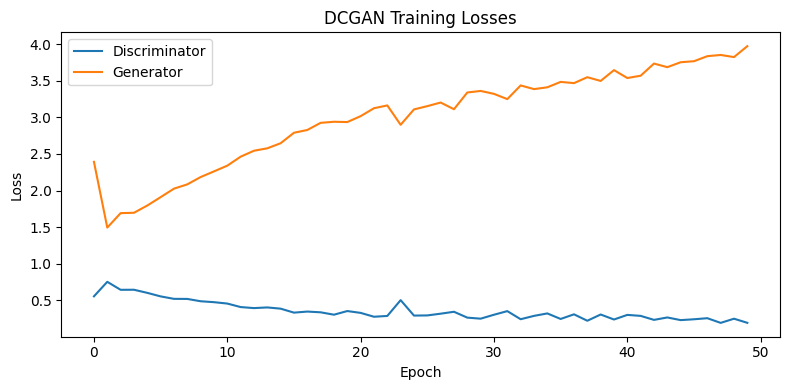

In [10]:
plt.figure(figsize=(8,4))
plt.plot(d_losses,label='Discriminator'); plt.plot(g_losses,label='Generator')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('DCGAN Training Losses')
plt.legend(); plt.tight_layout(); plt.savefig('samples/loss_curve.png'); plt.show()

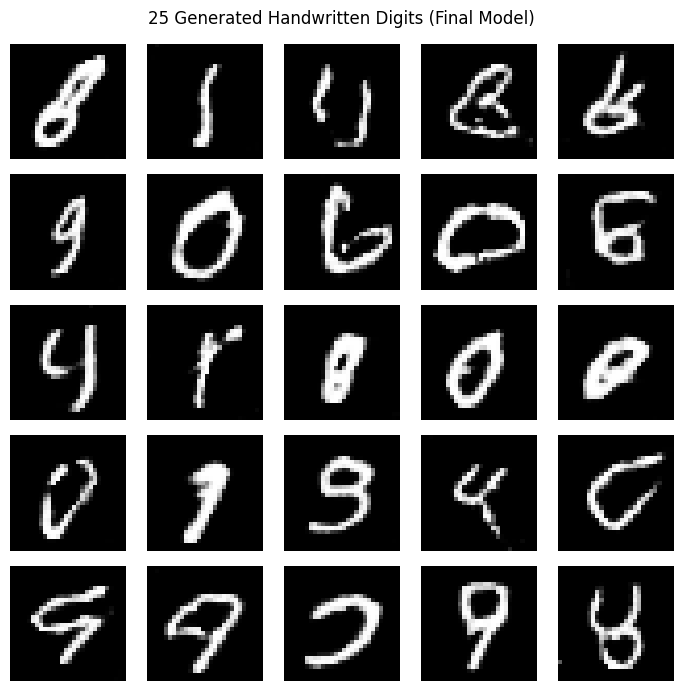

In [11]:
G.eval()
with torch.no_grad():
    z_f=torch.randn(25,LATENT_DIM,device=device)
    fi=G(z_f).cpu()
fig,axes=plt.subplots(5,5,figsize=(7,7))
for ax,im in zip(axes.flat,fi): ax.imshow(im.squeeze(),cmap='gray',vmin=-1,vmax=1); ax.axis('off')
plt.suptitle('25 Generated Handwritten Digits (Final Model)',fontsize=12)
plt.tight_layout(); plt.savefig('samples/final_generated.png',bbox_inches='tight'); plt.show()

In [12]:
torch.save(G.state_dict(),'samples/generator.pth')
torch.save(D.state_dict(),'samples/discriminator.pth')
print('Saved model weights to samples/')

Saved model weights to samples/


## Discussion

**What worked:**
- DCGAN paper's architecture choices (BatchNorm, LeakyReLU 0.2, Adam beta1=0.5) gave stable training.
- Normalizing MNIST to [-1,1] to match Tanh is essential for convergence.
- 50 epochs sufficient; recognizable digits appear by epoch 20.

**Common GAN failure modes:**
- **Mode collapse**: G maps many noise vectors to the same output. Mitigated by training D and G for equal steps.
- **Vanishing gradients for G**: D becomes too strong. Balanced here by alternating one step each per batch.
- **Loss oscillation**: Normal in GANs -- both losses fluctuate rather than converging to a fixed point.

**Takeaway:** The adversarial framework learns a generator distribution that matches real data without an explicit pixel-level loss, using the discriminator as a learned, adaptive critic.